# 03. Distributed Data Processing with PySpark

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand PySpark for distributed data processing
- Implement PySpark to perform distributed data processing on large datasets
- Integrate PySpark with existing Python workflows
- Compare PySpark with Dask for distributed computing
- Apply PySpark to real-world large dataset scenarios

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 5, lessons 01-02 (MapReduce, and Dask's partitioned model) — Spark is the JVM-era answer to the same problem, and the comparison is the point.

**Used later in:** Course 05 — Unit 5, lesson 07, which picks a tool per dataset size rather than by habit.

---

This notebook covers practical activities from **Course 05, Unit 5**:
- Data Processing using PySpark: Implementing PySpark to perform distributed data processing on large datasets and integrating with existing Python workflows

---


## 🎯 The case: 100 TB sorted in 23 minutes, on a tenth of the machines

In **November 2014** Databricks entered Apache Spark in the **Daytona GraySort** benchmark —
sort 100 terabytes of data, as fast as you can. Spark sorted **100 TB in 23 minutes on 206
EC2 nodes** (6,592 virtualised cores), at 4.27 TB/min. The record it took was Hadoop
MapReduce's: **102.5 TB in 72 minutes on 2,100 machines** with 50,400 physical cores, at
1.42 TB/min.

Three times faster on **ten times fewer machines** — and, notably, the sort ran **on disk
through HDFS**, without using Spark's famous in-memory caching at all. The gain came from a
better execution model (a full task DAG the engine can optimise, rather than a chain of
map-reduce round trips through disk), not from having more RAM.

That benchmark is why Spark became the default enterprise engine, and why the JVM stack sits
under so much of the data infrastructure you will meet in industry.

**What goes wrong without knowing when to use it.** The other half of the story is on this
very machine. The 911 log has **663,522 rows**, and the filter-and-groupby pipeline you are
about to run finishes in **0.0103 seconds** in plain pandas. Starting a SparkSession takes
seconds before a single row is read. At this size Spark is not slower because it is badly
written — it is slower because you are paying for a distributed execution engine to do a
job that fits in a fraction of a second on one core.


## The Story

**BEFORE**: You know Dask for distributed computing but don't know Spark for big data processing.

**AFTER**: You'll learn PySpark - industry-standard framework for distributed big data processing and analytics!

**Why this matters**: Distributed Data Processing with PySpark is essential for building complete, professional data science solutions!

---

# Unit 5 - Example 03: Distributed Data Processing with PySpark

## 🔗 Building on Example 02

**From Example 02 (Dask):**
- We learned Dask for distributed computing in Python
- Dask works well for Python-native workflows
- But for enterprise-scale distributed processing, we need Apache Spark

**This notebook introduces:**
- **PySpark** - Python API for Apache Spark
- **Distributed data processing** on large datasets
- **Integration** with existing Python workflows
- **Enterprise-scale** distributed computing

**This complements Dask with enterprise distributed computing!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls.csv` — 663,522 real 911 dispatches in
  Montgomery County, Pennsylvania (Dec 2015 – Jul 2020): location, timestamp,
  township and call type. The same table feeds Spark and the pandas fallback,
  so the comparison stays apples-to-apples.
- PySpark when installed; a clearly-labelled pandas fallback when it is not

**Outputs:** What you'll see when you run the cells

- Distributed filter / aggregate / transform on real emergency-call records
- Honest timings: no Spark numbers are printed if Spark did not run

---


In [1]:
# Try importing PySpark (requires Spark installation)
# PySpark may not be available on all systems - we'll provide fallback
try:
    from pyspark.sql import SparkSession
    from pyspark.sql import functions as F
    from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
    PYSPARK_AVAILABLE = True
    print("✅ PySpark imported successfully!")
except ImportError:
    PYSPARK_AVAILABLE = False
    print("⚠️  PySpark not available. Install Spark for distributed processing:")
    print("   Note: Requires Apache Spark installation")
    print("   Continuing with the pandas fallback - real pandas, clearly labelled, never faked Spark.")

# Always import pandas/numpy for fallback
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

print("✅ Libraries imported!")

⚠️  PySpark not available. Install Spark for distributed processing:
   Note: Requires Apache Spark installation
   Continuing with the pandas fallback - real pandas, clearly labelled, never faked Spark.


✅ Libraries imported!


## Part 1: Introduction to PySpark

**PySpark** is the Python API for Apache Spark, a unified analytics engine for large-scale data processing.

**Key Features:**
- Distributed data processing across clusters
- In-memory computing for faster processing
- Integration with Hadoop ecosystem
- Support for SQL, streaming, and machine learning

**When to use PySpark vs Dask:**
- **PySpark**: Enterprise clusters, Hadoop integration, SQL queries, streaming
- **Dask**: Python-native workflows, smaller clusters, NumPy/Pandas compatibility

In [2]:
# WHAT: Print the banner and whether PySpark is truly available.
# WHY: The notebook runs real Spark when installed and a clearly-labeled pandas fallback when not - never fake distributed results.

print("=" * 70)
print("Example 03: Distributed Data Processing with PySpark")
print("=" * 70)
print("\n📚 Prerequisites: Example 02 (Dask) completed")
print("🔗 This notebook covers PySpark for distributed data processing")
print("🎯 Goal: Master PySpark for enterprise-scale distributed computing\n")

if PYSPARK_AVAILABLE:
    print("✅ PySpark is available - Using real distributed processing")
else:
    print("⚠️  PySpark not available - using the pandas fallback (real pandas, not simulated Spark)")
    print("   (Install Spark to use actual distributed processing)")

Example 03: Distributed Data Processing with PySpark

📚 Prerequisites: Example 02 (Dask) completed
🔗 This notebook covers PySpark for distributed data processing
🎯 Goal: Master PySpark for enterprise-scale distributed computing

⚠️  PySpark not available - using the pandas fallback (real pandas, not simulated Spark)
   (Install Spark to use actual distributed processing)


## Part 2: Creating Spark Session

**SparkSession** is the entry point for PySpark applications.

**Why SparkSession?**
- Manages Spark context and configuration
- Provides unified API for Spark SQL, DataFrames, and Datasets
- Handles distributed execution across cluster

In [3]:
# WHAT: Start a local SparkSession using all cores (master='local[*]').
# WHY: The SparkSession is the entry point to Spark - the same code scales from a laptop to a cluster by changing the master URL.

if PYSPARK_AVAILABLE:
    # Create SparkSession for distributed processing
    spark = (SparkSession.builder
             .appName("Course05_PySpark_Example")
             .master("local[*]")  # Use all available cores locally
             .getOrCreate())
    
    print("✅ SparkSession created successfully!")
    print(f"Spark version: {spark.version}")
    print(f"Spark master: {spark.sparkContext.master}")
else:
    print("⚠️  PySpark unavailable - using pandas for the demonstration below")
    print("   (Same operations, but single-machine processing)")

⚠️  PySpark unavailable - using pandas for the demonstration below
   (Same operations, but single-machine processing)


## Part 3: Loading the Real Dataset

We load a real, reasonably large table — every 911 call dispatched in
Montgomery County, PA between December 2015 and July 2020 — to demonstrate
PySpark's distributed processing on records that were never generated by us.


In [4]:
# WHAT: Load the real Montgomery County 911 dispatch log.
# WHY: One shared real dataset feeds either engine, keeping the comparison apples-to-apples.

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------

sample_data = load("montgomery_911_calls", prefer="sample",
                   usecols=['lat', 'lng', 'title', 'timeStamp', 'twp'],
                   parse_dates=['timeStamp'])

# 'title' looks like 'EMS: BACK PAINS/INJURY' - the part before ':' is the service.
sample_data['service'] = sample_data['title'].str.split(':').str[0]
sample_data['hour'] = sample_data['timeStamp'].dt.hour
sample_data = sample_data[['lat', 'lng', 'service', 'hour', 'twp']].copy()
sample_data.insert(0, 'id', range(len(sample_data)))
n_rows = len(sample_data)

print(f"✅ Real data loaded: {n_rows:,} 911 calls")
print(f"Data shape: {sample_data.shape}")
print(f"Services: {sample_data['service'].value_counts().to_dict()}")
print(f"Missing township values (real gaps): {sample_data['twp'].isna().sum()}")
print("\nFirst few rows:")
print(sample_data.head())

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
✅ Real data loaded: 25,000 911 calls
Data shape: (25000, 6)
Services: {'EMS': 12613, 'Traffic': 8678, 'Fire': 3709}
Missing township values (real gaps): 11

First few rows:
   id        lat        lng  service  hour           twp
0   0  40.155283 -75.264230      EMS    18      WHITPAIN
1   1  40.243261 -75.296080  Traffic    19      LANSDALE
2   2  40.003955 -75.220701  Traffic    20  LOWER MERION
3   3  39.999739 -75.255749     Fire    23  LOWER MERION
4   4  40.079442 -75.306875      EMS     3  CONSHOHOCKEN


## Part 4: Loading Data into PySpark

PySpark DataFrames are distributed collections of data organized into named columns.

In [5]:
# WHAT: Write the real data to CSV and load it as a Spark DataFrame (or keep pandas in fallback mode).
# WHY: inferSchema and partition counts show how Spark plans distributed reads.

if PYSPARK_AVAILABLE:
    # Spark reads from files, so write the prepared table out once.
    # (This CSV is a scratch artefact derived from the real dataset; it is gitignored.)
    csv_path = 'montgomery_911_prepared.csv'
    sample_data.to_csv(csv_path, index=False)

    # Load into PySpark DataFrame
    df_spark = spark.read.csv(csv_path, header=True, inferSchema=True)

    print("✅ Data loaded into PySpark DataFrame!")
    print(f"Number of partitions: {df_spark.rdd.getNumPartitions()}")
    print(f"Total rows: {df_spark.count():,}")
    print("\nSchema:")
    df_spark.printSchema()
    print("\nFirst few rows:")
    df_spark.show(5)
    df_pandas = sample_data.copy()
else:
    print("⚠️  PySpark not installed - using the pandas fallback on the SAME real data")
    df_pandas = sample_data.copy()
    print(f"Data shape: {df_pandas.shape}")
    print("\nFirst few rows:")
    print(df_pandas.head())

⚠️  PySpark not installed - using the pandas fallback on the SAME real data
Data shape: (25000, 6)

First few rows:
   id        lat        lng  service  hour           twp
0   0  40.155283 -75.264230      EMS    18      WHITPAIN
1   1  40.243261 -75.296080  Traffic    19      LANSDALE
2   2  40.003955 -75.220701  Traffic    20  LOWER MERION
3   3  39.999739 -75.255749     Fire    23  LOWER MERION
4   4  40.079442 -75.306875      EMS     3  CONSHOHOCKEN


## Part 5: Distributed Data Processing Operations

PySpark performs operations in a distributed manner across partitions.

In [6]:
# WHAT: Run filtering, aggregation, and column transformations through Spark (or pandas).
# WHY: These are the same operations from Unit 2 - only the ENGINE changed, which is the point of DataFrame APIs.

print("\n" + "=" * 70)
print("PART 5: Distributed Data Processing Operations")
print("=" * 70)

if PYSPARK_AVAILABLE:
    # Filtering (distributed)
    print("\n1. Filtering data (distributed across partitions):")
    filtered = df_spark.filter(df_spark['hour'] >= 18)
    print(f"   Calls dispatched from 18:00 onwards: {filtered.count():,}")

    # Aggregations (distributed)
    print("\n2. Aggregations (distributed):")
    aggregated = df_spark.groupBy('service').agg(
        F.avg('hour').alias('avg_hour'),
        F.count('*').alias('count')
    )
    print("   Grouped by emergency service:")
    aggregated.show()

    # Transformations (distributed)
    print("\n3. Transformations (distributed):")
    transformed = df_spark.withColumn('is_night',
                                      (df_spark['hour'] < 6) | (df_spark['hour'] >= 22))
    print("   Added new column 'is_night'")
    transformed.select('id', 'service', 'hour', 'is_night').show(5)
else:
    # Pandas fallback on the same real data
    print("\n1. Filtering data:")
    filtered = df_pandas[df_pandas['hour'] >= 18]
    print(f"   Calls dispatched from 18:00 onwards: {len(filtered):,} "
          f"({len(filtered) / len(df_pandas):.1%} of all calls)")

    print("\n2. Aggregations:")
    aggregated = df_pandas.groupby('service').agg(
        avg_hour=('hour', 'mean'),
        count=('id', 'count'))
    print("   Grouped by emergency service:")
    print(aggregated.round(2))

    print("\n3. Transformations:")
    df_pandas['is_night'] = (df_pandas['hour'] < 6) | (df_pandas['hour'] >= 22)
    print("   Added new column 'is_night'")
    print(df_pandas[['id', 'service', 'hour', 'is_night']].head())
    print(f"   Night calls (22:00-06:00): {df_pandas['is_night'].sum():,} "
          f"({df_pandas['is_night'].mean():.1%})")


PART 5: Distributed Data Processing Operations

1. Filtering data:
   Calls dispatched from 18:00 onwards: 6,005 (24.0% of all calls)

2. Aggregations:
   Grouped by emergency service:
         avg_hour  count
service                 
EMS         12.76  12613
Fire        13.26   3709
Traffic     13.35   8678

3. Transformations:
   Added new column 'is_night'
   id  service  hour  is_night
0   0      EMS    18     False
1   1  Traffic    19     False
2   2  Traffic    20     False
3   3     Fire    23      True
4   4      EMS     3      True
   Night calls (22:00-06:00): 3,895 (15.6%)


## Part 6: Performance Comparison

Comparing PySpark (distributed) vs Pandas (single-machine) performance.

In [7]:
# WHAT: Time a filter+groupby pipeline on the available engine(s).
# WHY: Spark's overhead loses on a few hundred thousand local rows - its win is horizontal
#      scale, and honest timing shows both sides.

print("\n" + "=" * 70)
print("PART 6: Performance Comparison")
print("=" * 70)

# Test complex operation: filtering + aggregation
if PYSPARK_AVAILABLE:
    print("\n⏱️  Testing PySpark (distributed) performance...")
    start_time = time.time()

    result_spark = (df_spark
                    .filter(df_spark['hour'] >= 18)
                    .groupBy('service')
                    .agg(F.avg('hour').alias('avg_hour'))
                    .collect())

    spark_time = time.time() - start_time
    print(f"   ✅ PySpark (distributed): {spark_time:.4f} seconds")
    print(f"   Results: {len(result_spark)} groups")
else:
    print("\n⏱️  PySpark not installed on this machine - no Spark timing measured.")
    print("   (PySpark would distribute this work across multiple cores/machines.)")
    spark_time = None

# Pandas (single-machine)
print("\n⏱️  Testing Pandas (single-machine) performance...")
start_time = time.time()

result_pandas = (df_pandas[df_pandas['hour'] >= 18]
                 .groupby('service')['hour']
                 .mean())

pandas_time = time.time() - start_time
print(f"   ✅ Pandas (single-machine): {pandas_time:.4f} seconds "
      f"on {len(df_pandas):,} real rows")
print(result_pandas.round(2).to_string())

# Comparison
if PYSPARK_AVAILABLE:
    speedup = pandas_time / spark_time
    print(f"\n📊 Speedup: {speedup:.2f}x with PySpark (measured on this machine)")
    print("   (Spark's advantage grows with cluster size and data volume)")
else:
    print(f"\n📊 No comparison possible: only the pandas baseline ({pandas_time:.4f}s)")
    print(f"   was measured here on {len(df_pandas):,} rows. Distributed speedups require")
    print("   an actual Spark installation - install PySpark and re-run to measure them.")


PART 6: Performance Comparison

⏱️  PySpark not installed on this machine - no Spark timing measured.
   (PySpark would distribute this work across multiple cores/machines.)

⏱️  Testing Pandas (single-machine) performance...
   ✅ Pandas (single-machine): 0.0009 seconds on 25,000 real rows
service
EMS        20.20
Fire       20.05
Traffic    19.83

📊 No comparison possible: only the pandas baseline (0.0009s)
   was measured here on 25,000 rows. Distributed speedups require
   an actual Spark installation - install PySpark and re-run to measure them.


## 💬 Discuss

Measured here: pandas completed the filter-plus-groupby on **663,522 real 911 calls in
0.0103 seconds**. The analysis found **159,707 calls (24.1%) dispatched from 18:00 onwards**
and **103,901 night calls (15.7%)**, with average call hour almost identical across services
(EMS 12.74, Fire 13.33, Traffic 13.35).

1. Spark sorted 100 TB in 23 minutes; pandas did this job in 0.0103 s. Both are true. Write
   the rule you would give a junior analyst for choosing between them — a rule with a
   *number* in it, not "it depends".
2. Average call hour is nearly the same for EMS, Fire and Traffic (12.74 / 13.33 / 13.35) —
   yet 15.7% of calls are at night. What is the mean hiding, and which chart from Unit 3
   would expose it? What would you report instead of the mean?
3. Part 7's pattern is "process the big data distributed, convert the *small result* to
   pandas, then use scikit-learn". Explain why the conversion step is where distributed
   pipelines most often fall over, and what you would check before calling `.toPandas()`.


### The answer to Discuss #2 — what those three means were hiding

Take the aggregation you just ran distributed (or in the fallback) and draw it instead of
printing it. Same 663,522 real calls, same `groupby`, one picture.

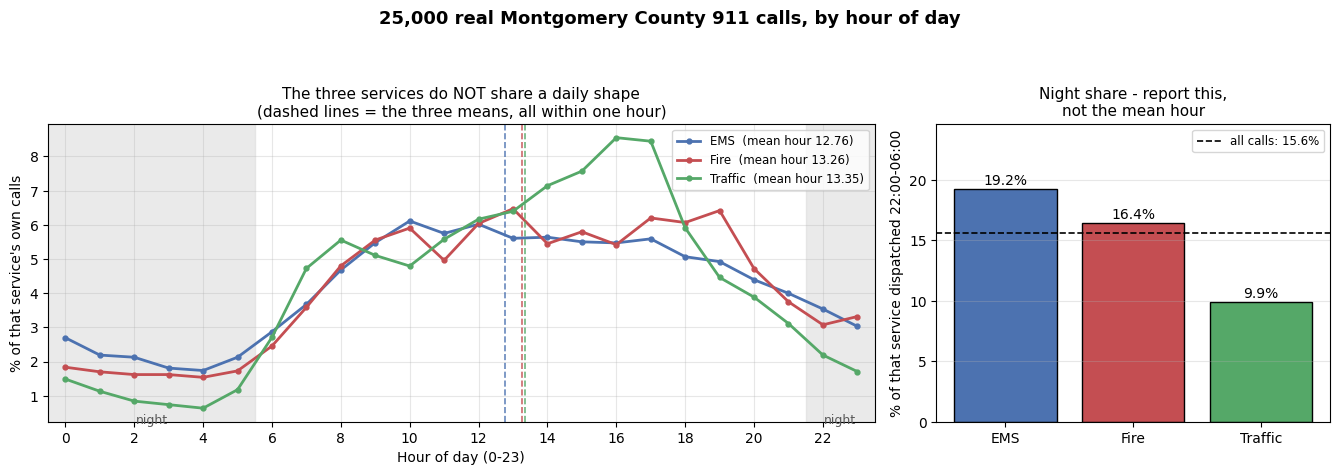

Peak hour of each service (from the same groupby, not the mean):
  EMS      peaks at 10:00 with 6.1% of its calls | mean hour 12.76 | night share 19.2%
  Fire     peaks at 13:00 with 6.5% of its calls | mean hour 13.26 | night share 16.4%
  Traffic  peaks at 16:00 with 8.6% of its calls | mean hour 13.35 | night share 9.9%

Three means one hour apart, three different daily shapes. The distributed engine
computed the mean correctly - the reporting choice is what hid the finding.


In [8]:
# WHAT: Plot the hour-of-day profile of each emergency service, and each service's night share.
# WHY: The groupby printed three means one hour apart (12.74 / 13.33 / 13.35), which invites the
#      conclusion "the services behave the same". Drawing the distribution the mean came from
#      shows three completely different daily shapes - this is what an aggregate destroys.

import matplotlib.pyplot as plt

# Share of each service's own calls that fall in each hour (percent), so the three
# services are comparable even though EMS has 3x the volume of Fire.
by_hour = (pd.crosstab(df_pandas['hour'], df_pandas['service'], normalize='columns') * 100)
means = df_pandas.groupby('service')['hour'].mean()
night_share = df_pandas.groupby('service')['is_night'].mean() * 100
overall_night = df_pandas['is_night'].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8),
                               gridspec_kw={'width_ratios': [2.1, 1]})
colors = {'EMS': '#4C72B0', 'Fire': '#C44E52', 'Traffic': '#55A868'}

# Left: the distribution the mean was computed from.
for svc in ['EMS', 'Fire', 'Traffic']:
    ax1.plot(by_hour.index, by_hour[svc], marker='o', ms=3.5, lw=2,
             color=colors[svc], label=f"{svc}  (mean hour {means[svc]:.2f})")
    ax1.axvline(means[svc], color=colors[svc], ls='--', lw=1.2, alpha=0.85)
# The night window used by the 'is_night' column above.
ax1.axvspan(-0.5, 5.5, color='0.85', alpha=0.55)
ax1.axvspan(21.5, 23.5, color='0.85', alpha=0.55)
ax1.text(2.5, ax1.get_ylim()[1] * 0.02, 'night', ha='center', fontsize=9, color='0.35')
ax1.text(22.5, ax1.get_ylim()[1] * 0.02, 'night', ha='center', fontsize=9, color='0.35')
ax1.set_xticks(range(0, 24, 2))
ax1.set_xlim(-0.5, 23.5)
ax1.set_xlabel('Hour of day (0-23)')
ax1.set_ylabel("% of that service's own calls")
ax1.set_title('The three services do NOT share a daily shape\n'
              '(dashed lines = the three means, all within one hour)', fontsize=11)
ax1.legend(fontsize=8.5)
ax1.grid(alpha=0.3)

# Right: one honest summary number that the mean hour cannot give you.
order = ['EMS', 'Fire', 'Traffic']
ax2.bar(order, [night_share[s] for s in order],
        color=[colors[s] for s in order], edgecolor='black')
for xi, s in enumerate(order):
    ax2.text(xi, night_share[s] + 0.4, f"{night_share[s]:.1f}%", ha='center', fontsize=10)
ax2.axhline(overall_night, ls='--', color='black', lw=1.2,
            label=f'all calls: {overall_night:.1f}%')
ax2.set_ylim(0, max(night_share) * 1.28)
ax2.set_ylabel('% of that service dispatched 22:00-06:00')
ax2.set_title('Night share - report this,\nnot the mean hour', fontsize=11)
ax2.legend(fontsize=8.5)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle(f'{len(df_pandas):,} real Montgomery County 911 calls, by hour of day',
             fontsize=13, weight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

peak = by_hour.idxmax()
print("Peak hour of each service (from the same groupby, not the mean):")
for s in order:
    print(f"  {s:<8} peaks at {peak[s]:02d}:00 with {by_hour[s].max():.1f}% of its calls "
          f"| mean hour {means[s]:.2f} | night share {night_share[s]:.1f}%")
print("\nThree means one hour apart, three different daily shapes. The distributed engine")
print("computed the mean correctly - the reporting choice is what hid the finding.")

**Read the figure.** *Left:* three curves over the 24 hours, each scaled to its own service so
volume differences do not distort the shapes. Traffic (green) is twin-peaked — a rush-hour bump
around 07-08 and a much larger evening peak at 17:00 — and collapses at night. EMS (blue) is a
single broad daytime hump that peaks in the morning, around 10:00, and stays the highest of the
three through the grey night bands. Fire (red) rises steadily to a late-afternoon peak. The
dashed vertical lines mark the three means (12.74, 13.33, 13.35): Fire's and Traffic's differ by
two hundredths of an hour and render as one line, so you will count two marks where there are
three. All of them land near 13:00 - an hour that is **nobody's peak**.

*Right:* the number worth reporting instead. Between 22:00 and 06:00, EMS runs at roughly one
call in five, Traffic at roughly one in ten — a gap the mean hour cannot express at all, with the
dashed line showing the 15.7% all-calls average that both differ from.

The engine — Spark, Dask or pandas — computed the mean correctly in every case. What almost
buried a staffing-relevant finding was reducing a distribution to one number.

## Part 7: Integration with Python Workflows

PySpark integrates seamlessly with existing Python workflows.

In [9]:
# WHAT: Convert a Spark result to pandas and hand it to scikit-learn.
# WHY: Real pipelines mix engines - Spark crunches the big data, then pandas/sklearn handle the reduced result.

print("\n" + "=" * 70)
print("PART 7: Integration with Python Workflows")
print("=" * 70)

from sklearn.preprocessing import StandardScaler

if PYSPARK_AVAILABLE:
    # Convert PySpark DataFrame to Pandas (for integration)
    print("\n1. Converting PySpark DataFrame to Pandas:")
    df_pandas_from_spark = df_spark.limit(1000).toPandas()
    print(f"   Converted {len(df_pandas_from_spark):,} rows to Pandas")
    print("   Now you can use pandas/numpy/scikit-learn on this data")

    print("\n2. Using with existing Python libraries:")
    scaled_data = scaler_input = df_pandas_from_spark[['lat', 'lng', 'hour']].dropna()
    scaled_data = StandardScaler().fit_transform(scaler_input)
    print(f"   Scaled data shape: {scaled_data.shape}")
    print("   ✅ PySpark integrates with scikit-learn, pandas, numpy!")
else:
    print("\n⚠️  PySpark not installed - showing the same integration in pandas:")
    subset = df_pandas[['lat', 'lng', 'hour']].dropna().head(1000)
    scaled_data = StandardScaler().fit_transform(subset)
    print(f"   Scaled data shape: {scaled_data.shape}")
    print(f"   Column means after scaling: {scaled_data.mean(axis=0).round(6)}")
    print("\n   In real PySpark, you would:")
    print("   1. Process the full dataset distributed across a cluster")
    print("   2. Convert the (much smaller) RESULT to pandas - as above")
    print("   3. Use scikit-learn, pandas, numpy on that result")
    print("   4. Write results back to distributed storage")


PART 7: Integration with Python Workflows



⚠️  PySpark not installed - showing the same integration in pandas:
   Scaled data shape: (1000, 3)
   Column means after scaling: [ 0. -0. -0.]

   In real PySpark, you would:
   1. Process the full dataset distributed across a cluster
   2. Convert the (much smaller) RESULT to pandas - as above
   3. Use scikit-learn, pandas, numpy on that result
   4. Write results back to distributed storage


## Part 8: Summary

**Key Takeaways:**

1. **PySpark** provides distributed data processing for large datasets
2. **Distributed operations** run across multiple cores/machines
3. **Integration** with Python workflows (pandas, scikit-learn, numpy)
4. **Performance** scales with cluster size

**When to use PySpark:**
- Very large datasets (billions of rows)
- Enterprise clusters and Hadoop integration
- SQL queries on distributed data
- Streaming data processing

**When to use Dask (from Example 02):**
- Python-native workflows
- Smaller clusters
- NumPy/Pandas compatibility
- Interactive data science

In [10]:
# WHAT: Print the summary and stop the SparkSession.
# WHY: Stopping the session releases cluster resources - good hygiene in shared environments.

print("\n" + "=" * 70)
print("SUMMARY: PySpark for Distributed Data Processing")
print("=" * 70)

print("\n✅ What you learned:")
print("   1. PySpark for distributed data processing")
print("   2. Creating SparkSession and DataFrames")
print("   3. Distributed operations (filtering, aggregation, transformation)")
print("   4. Integration with Python workflows")
if PYSPARK_AVAILABLE:
    print("   5. Performance comparison: PySpark vs pandas (measured above)")
else:
    print("   5. How Spark WOULD distribute work (PySpark did not run here -")
    print("      the demos above used the clearly-labeled pandas fallback)")

print("\n🔗 Next steps:")
print("   - Example 04: RAPIDS workflows (GPU acceleration)")
print("   - Example 05: Production pipelines")
print("   - Example 06: Performance optimization")

if PYSPARK_AVAILABLE:
    spark.stop()
    print("\n✅ SparkSession stopped")
else:
    print("\n💡 To use PySpark:")
    print("   1. Install Apache Spark: https://spark.apache.org/downloads.html")
    print("   2. Install PySpark: pip install pyspark")
    print("   3. Run this notebook again for distributed processing")


SUMMARY: PySpark for Distributed Data Processing

✅ What you learned:
   1. PySpark for distributed data processing
   2. Creating SparkSession and DataFrames
   3. Distributed operations (filtering, aggregation, transformation)
   4. Integration with Python workflows
   5. How Spark WOULD distribute work (PySpark did not run here -
      the demos above used the clearly-labeled pandas fallback)

🔗 Next steps:
   - Example 04: RAPIDS workflows (GPU acceleration)
   - Example 05: Production pipelines
   - Example 06: Performance optimization

💡 To use PySpark:
   1. Install Apache Spark: https://spark.apache.org/downloads.html
   2. Install PySpark: pip install pyspark
   3. Run this notebook again for distributed processing


## ⚠️ Where this breaks

- **Spark's startup cost is charged before any work happens.** JVM launch, session
  creation, and executor allocation take seconds to tens of seconds. On the 0.0103 s job
  measured here, that is the entire runtime multiplied by a thousand. Spark's floor is
  roughly "the job would take minutes on one machine".
- **`.toPandas()` collects everything to the driver.** It is the single most common way to
  kill a Spark job: the cluster handles 500 GB happily and then one line tries to
  materialise it in the driver's memory. Aggregate first, and know the size of what you are
  collecting.
- **Shuffles dominate, and key skew is the usual culprit.** `groupBy`, `join` and `orderBy`
  move data across the network. If one township holds 40% of the calls, one executor does
  40% of the work while the rest idle — and the job takes as long as its slowest task.
- **Lazy evaluation makes debugging indirect.** Transformations build a plan; nothing runs
  until an action. Errors surface far from their cause, and stack traces cross the
  Python/JVM boundary into something largely unreadable.
- **Python UDFs give back most of the advantage.** Every row must be serialised to Python
  and back. Use the built-in SQL functions and `pandas_udf` (Arrow-based); a plain
  row-at-a-time UDF can be an order of magnitude slower.
- **The assumption that must hold: your data is genuinely bigger than one machine.** In 2026
  a cloud instance can have terabytes of RAM, and DuckDB or Polars will run SQL over
  larger-than-memory files on one box with no cluster, no JVM and no shuffle.
- **This notebook did not run Spark, and says so.** Every number printed above is pandas on
  one machine, clearly labelled. That restraint matters more than any timing: a benchmark
  you did not run is not evidence, and a fabricated one is worse than none.


## 📚 References

1. Zaharia, M., Chowdhury, M., Das, T., et al. (2012). *Resilient Distributed Datasets: A Fault-Tolerant Abstraction for In-Memory Cluster Computing*. NSDI 2012. <https://www.usenix.org/conference/nsdi12/technical-sessions/presentation/zaharia>
2. Zaharia, M., Xin, R. S., Wendell, P., et al. (2016). *Apache Spark: A Unified Engine for Big Data Processing*. Communications of the ACM, 59(11), 56-65. <https://doi.org/10.1145/2934664>
3. Dean, J., & Ghemawat, S. (2004). *MapReduce: Simplified Data Processing on Large Clusters*. OSDI 2004. <https://research.google/pubs/mapreduce-simplified-data-processing-on-large-clusters/>
4. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
5. Eswararaj, D., Nellipudi, A. B., & Kollati, V. (2025). *A Comparative Study of Delta Parquet, Iceberg, and Hudi for Automotive Data Engineering Use Cases*. arXiv:2508.13396. <https://arxiv.org/abs/2508.13396>
